In [2]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

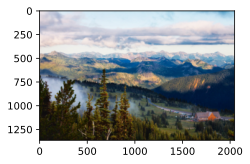

In [3]:
d2l.set_figsize()

content_img = d2l.Image.open('rainier.jpg')
d2l.plt.imshow(content_img)

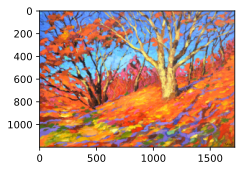

In [4]:
style_img = d2l.Image.open('autumn-oak.jpg')
d2l.plt.imshow(style_img)

In [5]:
rgb_mean = torch.tensor([0.485, 0.456, 0.406])
rgb_std = torch.tensor([0.229, 0.224, 0.225])

# 图片变成tensor
def preprocess(img, image_shape):
    transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize(image_shape),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=rgb_mean, std=rgb_std)
    ])
    return transforms(img=img).unsqueeze(0)

# 将tensor变成图片
def postprocess(img):
    img = img[0].to(rgb_std.device)
    img = torch.clamp(img.permute(1, 2, 0) * rgb_std + rgb_mean, 0, 1) 
    return torchvision.transforms.ToPILImage()(img.permute(2, 0, 1))

抽取图像特征

In [7]:
pretrained_net = torchvision.models.vgg19(pretrained=True)

# 定义哪些层来抽取特征
style_layers, content_layers = [0, 5, 10, 19, 28], [25]  

# 只需要用前 28 层
net = nn.Sequential(*[
    pretrained_net.features[i] for i in range(max(content_layers + style_layers) + 1)  # max([25, 0, 5, 10, 19, 28]) + 1 = 28 + 1 = 29
])

# 抽取特征
def extract_features(X, content_layers, style_layers):
    contents = []
    styles = []
    for i in range(len(net)):
        X = net[i](X)
        if i in style_layers:
            styles.append(X)
        if i in content_layers:
            contents.append(X)
    return contents, styles

def get_contents(image_shape, device):
    content_X = preprocess(content_img, image_shape).to(device)
    content_Y, _ = extract_features(content_X, content_layers, style_layers)
    return content_X, content_Y

def get_styles(image_shape, device):
    style_X = preprocess(style_img, image_shape).to(device)
    _, style_Y = extract_features(style_X, content_layers, style_layers)
    return style_X, style_Y 

c:\Users\86180\miniconda3\envs\deepLearn\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\86180\miniconda3\envs\deepLearn\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\86180/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [03:13<00:00, 2.97MB/s] 


定义损失函数

In [ ]:
def content_loss(Y_hat, Y):
    return torch.square(Y_hat - Y.detach()).mean()  # Y_detached 和 Y 数值一样，但不带梯度，不连计算图

# 对通道进行两两内积来确定图的风格，gram矩阵的计算除去了位置，只留下风格
def gram(X):
    # 张量的所有元素总数 = 通道数 * H * W
    num_channels, n = X.shape[1], X.numel() // X.shape[1]  # X.numel() = 张量里所有元素的总数 | X.numel() // X.shape[1] = 空间元素的总数
    # 展平空间维度
    X = X.reshape((num_channels, n))
    return torch.matmul(X, X.T) / (num_channels * n)

def style_loss(Y_hat, gram_Y):
    return torch.square(gram(Y_hat) - gram_Y.detach()).mean()
# 全变分损失
def tv_loss(Y_hat):
    return 0.5 * (torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]).mean() +
                  torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]).mean())

全变分损失（Total Variation）——去噪。

优化过程中画布会产生高频噪点（像素之间跳变剧烈），TV loss 惩罚相邻像素差异过大，让画面平滑。


横向：每行相邻像素的差异  
torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :])
                    ↑行号1~末尾    ↑行号0~倒数第二
                    相邻行相减

纵向：每列相邻像素的差异  
torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1])
                    ↑列号1~末尾    ↑列号0~倒数第二
                    相邻列相减

In [9]:
content_weight, style_weight, tv_weight = 1, 1e3, 10

def compute_loss(X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y):
    contents_l = [
        content_loss(Y_hat, Y) * content_weight for Y_hat, Y in zip(contents_Y_hat, contents_Y)
    ]
    styles_l = [
        style_loss(Y_hat, Y) * style_weight for Y_hat, Y in zip(styles_Y_hat, styles_Y)
    ]
    tv_l = tv_loss(X) * tv_weight

    l = sum(10 * styles_l + contents_l + [tv_l])
    return contents_l, styles_l, tv_l, l

In [10]:
# 把图片信息当作参数，并进行更新
class SynthesizedImage(nn.Module):
    def __init__(self, img_shape, **kwargs):
        super(SynthesizedImage, self).__init__(**kwargs)
        self.weight = nn.Parameter(torch.rand(*img_shape))

    def forward(self):
        return self.weight
    
def get_inits(X, device, lr, style_Y):
    # X是内容图像的预处理结果
    gen_img = SynthesizedImage(X.shape).to(device)
    # 将初始化的weight参数改为已有的图像X的参数（即像素）
    gen_img.weight.data.copy_(X.data)
    # 定义优化器
    trainer = torch.optim.Adam(gen_img.parameters(), lr=lr)
    # 对各风格特征图计算其格拉姆矩阵，并依次存于列表中
    style_Y_gram = [gram(Y) for Y in style_Y]

    return gen_img(), style_Y_gram, trainer

In [11]:
def train(X, contents_Y, styles_Y, device, lr, num_epochs, lr_decay_epoch):
    X, styles_Y_gram, trainer = get_inits(X, device, lr, styles_Y)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_decay_epoch, 0.8)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs],
                            legend=['content', 'style', 'TV'],
                            ncols=2, figsize=(7, 2.5))
    for epoch in range(num_epochs):
        trainer.zero_grad()
        contents_Y_hat, styles_Y_hat = extract_features(
            X, content_layers, style_layers)
        contents_l, styles_l, tv_l, l = compute_loss(
            X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram)
        l.backward()
        trainer.step()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            animator.axes[1].imshow(postprocess(X))
            animator.add(epoch + 1, [float(sum(contents_l)),
                                     float(sum(styles_l)), float(tv_l)])
    return X

训练模型

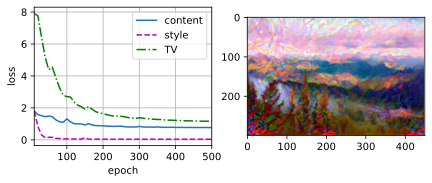

In [12]:
device = torch.device('cpu')
image_shape = (300, 450)  # 图片尺寸，CPU上别设太大，不然慢

net = net.to(device)
# 获取内容特征
content_X, content_Y = get_contents(image_shape, device)
# 获取风格特征和 Gram
_, style_Y = get_styles(image_shape, device)

# 原图初始化 + 训练
output = train(content_X, content_Y, style_Y, device, lr=0.3, num_epochs=500, lr_decay_epoch=50)